In [31]:
from sunpy.net import hek, hek2vso, attrs as a
import numpy as np

client = hek.HEKClient()
h2v = hek2vso.H2VClient()

tstart = '2013-01-20 00:00:00'
tend   = '2013-01-20 23:59:59'

filaments = client.search(
    a.Time(tstart, tend),
    hek.attrs.EventType('FI')
)

In [32]:
vso_records = h2v.translate_and_query(filaments[0]) # returns 11th filaments
print("Start time:", filaments['event_starttime'])
print("End time:", filaments['event_endtime'])
#print("Peak time:", filaments['event_peaktime'])

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.28s/records]

Start time: ['2013-01-20 08:17:52.000' '2013-01-20 08:17:52.000'
 '2013-01-20 08:17:52.000' '2013-01-20 08:17:52.000'
 '2013-01-20 08:17:52.000' '2013-01-20 08:17:52.000'
 '2013-01-20 08:17:52.000' '2013-01-20 08:17:52.000'
 '2013-01-20 08:17:52.000' '2013-01-20 08:17:52.000'
 '2013-01-20 08:17:52.000' '2013-01-20 08:17:52.000'
 '2013-01-20 08:17:52.000' '2013-01-20 08:17:52.000'
 '2013-01-20 08:17:52.000' '2013-01-20 08:17:52.000']
End time: ['2013-01-20 08:17:52.000' '2013-01-20 08:17:52.000'
 '2013-01-20 08:17:52.000' '2013-01-20 08:17:52.000'
 '2013-01-20 08:17:52.000' '2013-01-20 08:17:52.000'
 '2013-01-20 08:17:52.000' '2013-01-20 08:17:52.000'
 '2013-01-20 08:17:52.000' '2013-01-20 08:17:52.000'
 '2013-01-20 08:17:52.000' '2013-01-20 08:17:52.000'
 '2013-01-20 08:17:52.000' '2013-01-20 08:17:52.000'
 '2013-01-20 08:17:52.000' '2013-01-20 08:17:52.000']


In [33]:
# Step 5: Fetch a native-resolution AIA 304 Å map near filament times
# Step 0: imports
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.coordinates import SkyCoord
from sunpy.net import Fido, attrs as a
from sunpy.net import hek
import sunpy.map
import numpy as np

results = Fido.search(
    a.Time('2013-01-20 10:00', '2013-01-20 10:02'),  # pick a representative time
    a.Instrument.aia,
    a.Wavelength(193 * u.angstrom)
)

file = Fido.fetch(results[0, 0])
aia_map = sunpy.map.Map(file)  # native resolution 4096x4096


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Saved filament tracks image as filtered_filaments_new.png


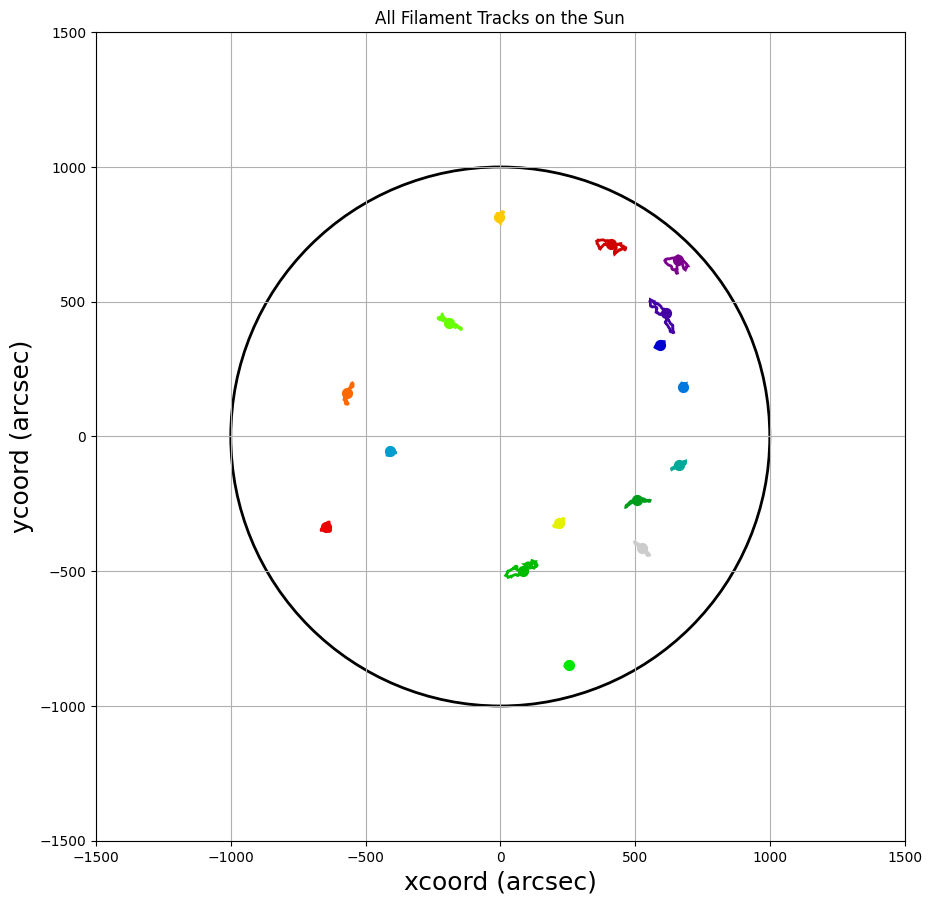

(<Figure size 1050x1050 with 1 Axes>,
 <Axes: title={'center': 'All Filament Tracks on the Sun'}, xlabel='xcoord (arcsec)', ylabel='ycoord (arcsec)'>)

In [34]:
from shapely import wkb
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
# plots all the filaments without separating timesteps taken at filaments[10 0r 1 or ...]
def PlotAllTracksFilteredSavePNG(filaments_table, png_filename="filaments_tracks.png"):
    """
    Plot all filaments from an Astropy Table,
    removing filaments with <=3 points, and save as PNG.
    """
    filaments = filaments_table.copy()

    # Add track numbers if missing
    if "trackno" not in filaments.colnames:
        filaments["trackno"] = range(1, len(filaments) + 1)

    track_numbers = sorted(set(filaments["trackno"]))

    # Color map
    cmap = plt.get_cmap('nipy_spectral')
    norm = mpl.colors.Normalize(vmin=0, vmax=max(track_numbers))
    m = cm.ScalarMappable(norm=norm, cmap=cmap)

    # Plot setup
    fig, ax = plt.subplots(figsize=(10.5, 10.5))
    ax.grid(True)
    ax.set_xlabel('xcoord (arcsec)', fontsize=18)
    ax.set_ylabel('ycoord (arcsec)', fontsize=18)
    ax.set_xlim(-1500, 1500)
    ax.set_ylim(-1500, 1500)
    ax.set_aspect('equal')

    # Solar disk
    sun_disk = plt.Circle((0, 0), radius=1000, linewidth=2, fill=False, color='black', zorder=1)
    ax.add_patch(sun_disk)

    # Loop over tracks
    for tn in track_numbers:
        color = m.to_rgba(tn)
        filaments_track = filaments[filaments["trackno"] == tn]

        # Plot eruption points
        xs = [x for x in filaments_track["hpc_x"] if x is not None]
        ys = [y for y in filaments_track["hpc_y"] if y is not None]
        ax.scatter(xs, ys, color=color, s=50, zorder=3)

        # Plot filament (first in track)
        filament_wkb_hex = filaments_track["hpc_geom"][0] if "hpc_geom" in filaments.colnames else None
        if filament_wkb_hex:
            try:
                poly = wkb.loads(bytes.fromhex(filament_wkb_hex))
            except Exception as e:
                print(f"Failed to parse filament WKB for track {tn}: {e}")
                continue

            # Filter out polygons with <=3 points
            def valid_polygon(polygon):
                return len(polygon.exterior.coords) > 3

            if poly:
                def plot_poly(polygon, color):
                    if valid_polygon(polygon):
                        ax.add_patch(plt.Polygon(polygon.exterior.coords,
                                                 linewidth=2, fill=False, color=color, zorder=2))

                if poly.geom_type == 'MultiPolygon':
                    for p in poly.geoms:
                        plot_poly(p, color)
                elif poly.geom_type == 'Polygon':
                    plot_poly(poly, color)
                else:
                    print(f"Unknown geometry type for track {tn}: {poly.geom_type}")

    ax.set_title('All Filament Tracks on the Sun')

    # --- Save PNG ---
    fig.savefig(png_filename, dpi=300, bbox_inches='tight')
    print(f"Saved filament tracks image as {png_filename}")

    # Optionally display
    plt.show()

    return fig, ax

# --- Usage ---
PlotAllTracksFilteredSavePNG(filaments, png_filename="filtered_filaments_new.png")


Saved AIA-resolution image: filtered_filaments_new.png


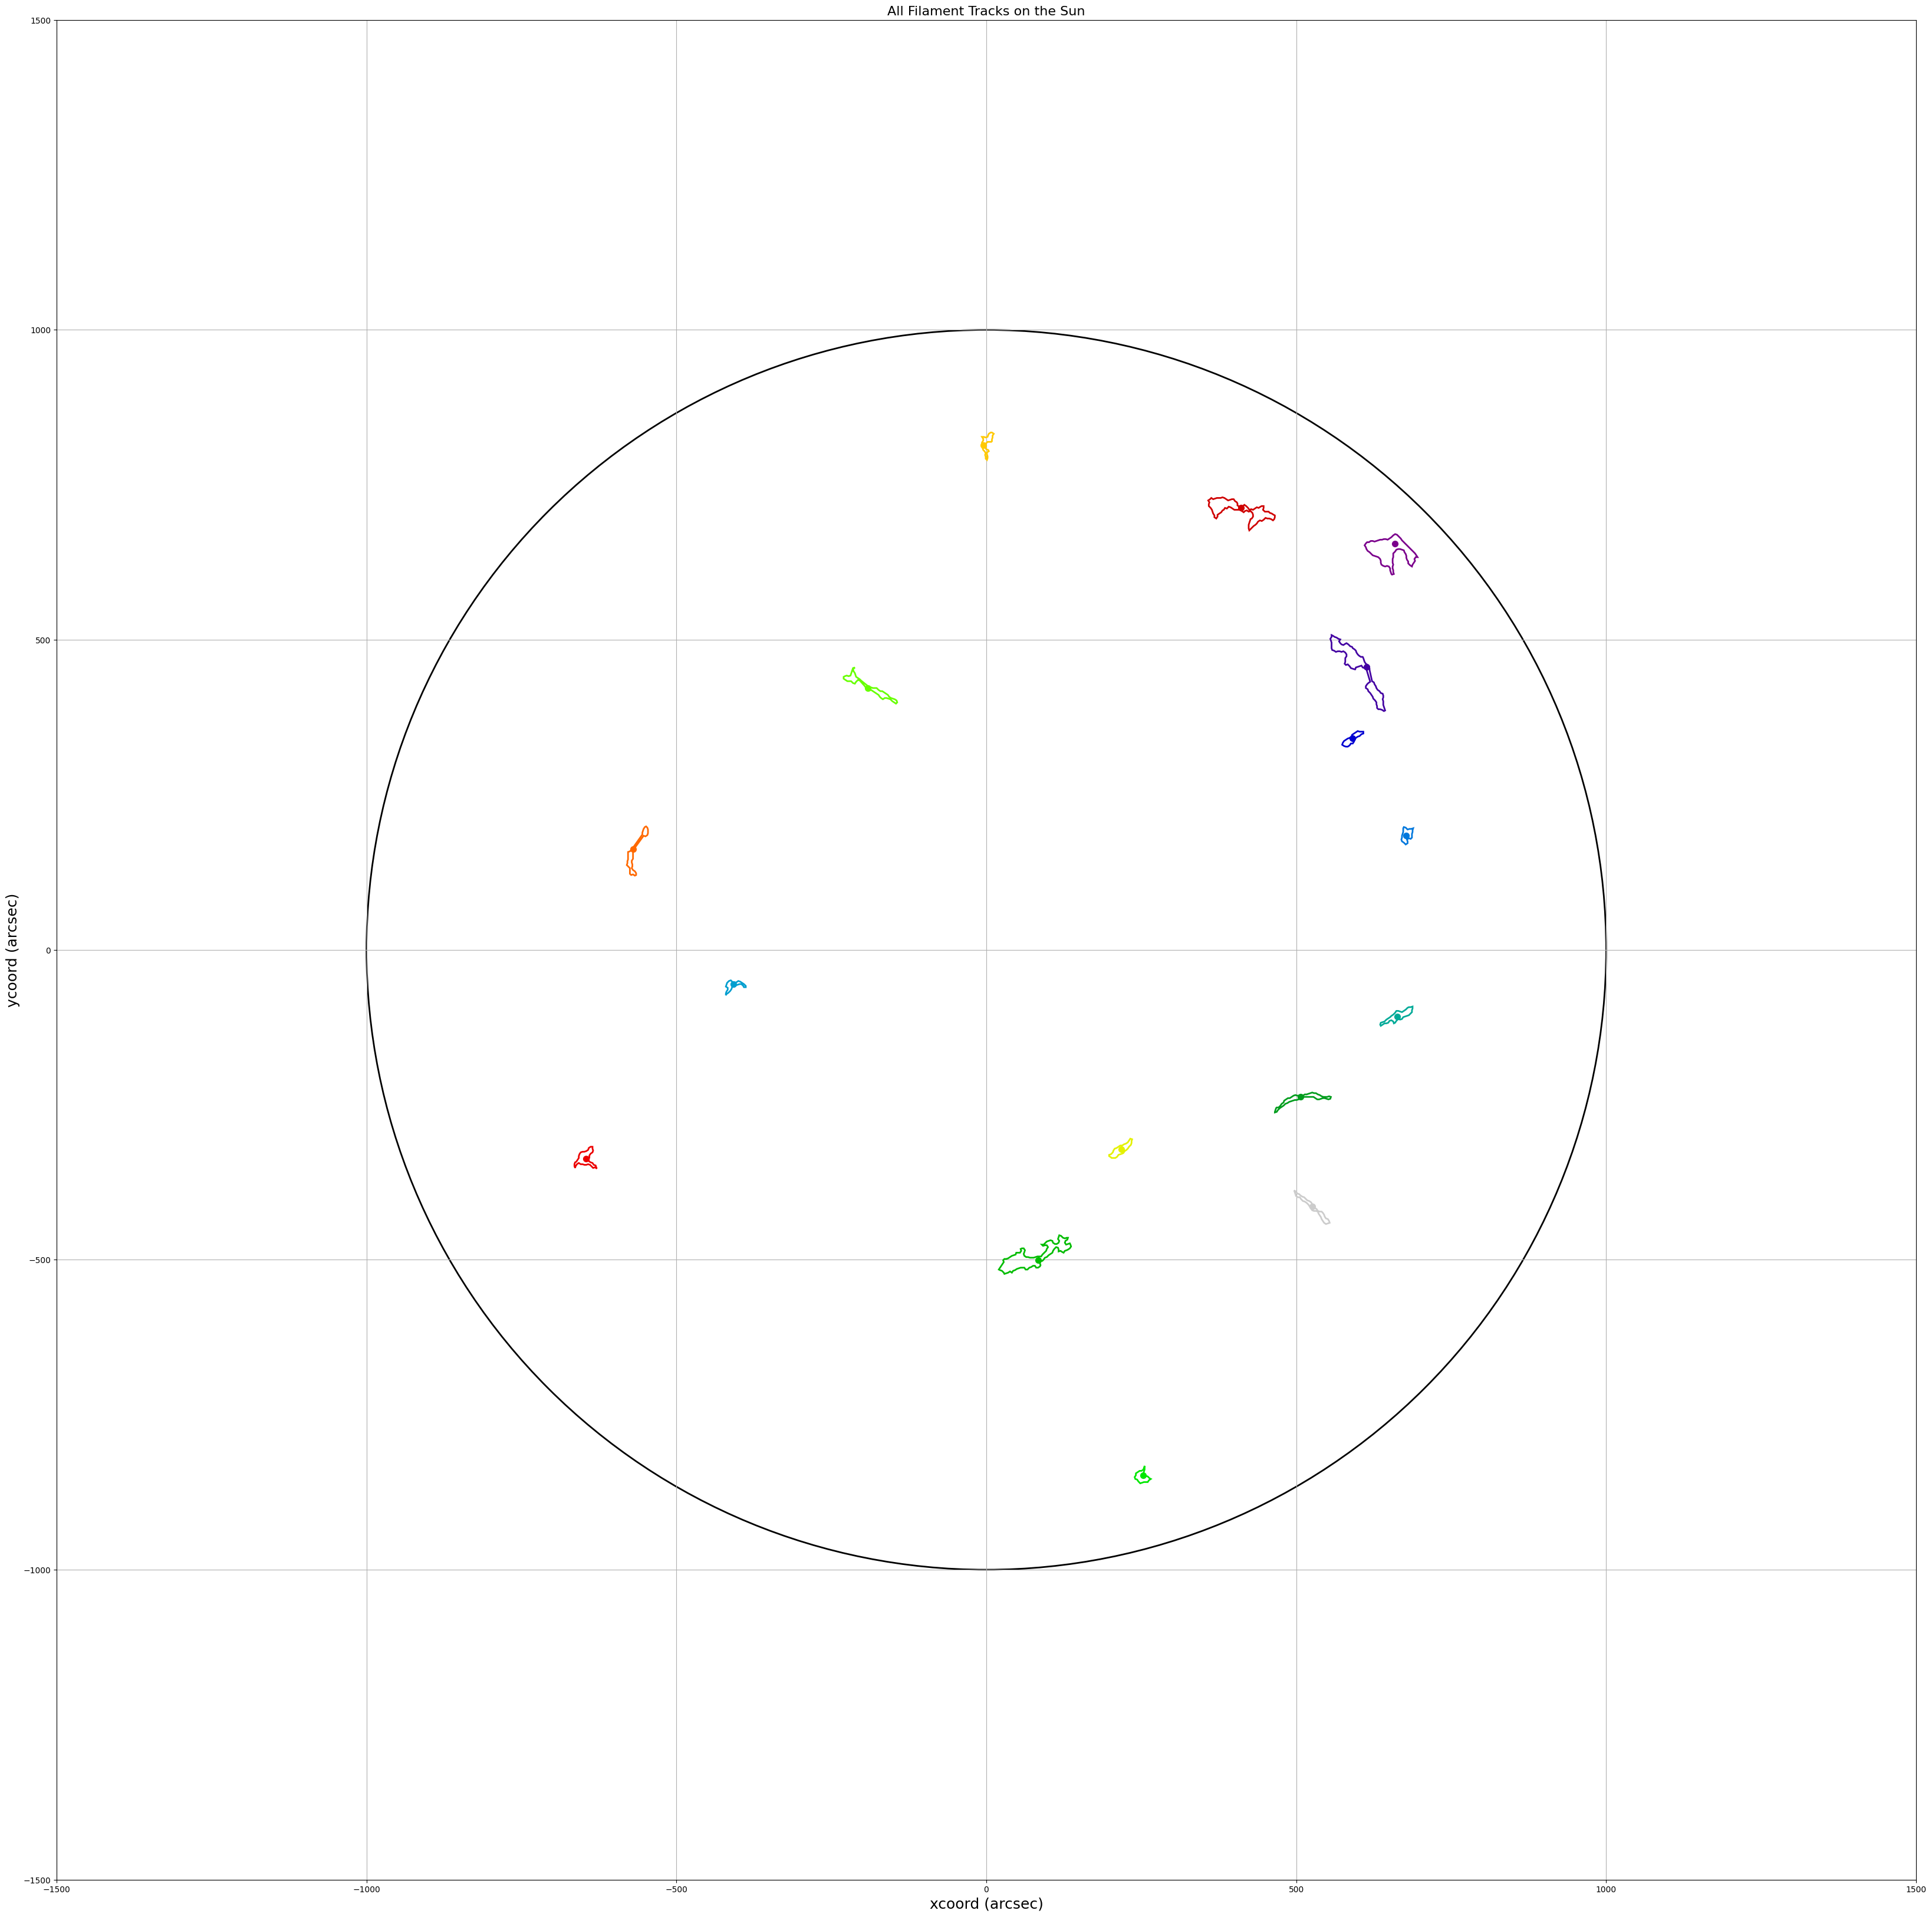

(<Figure size 4096x4096 with 1 Axes>,
 <Axes: title={'center': 'All Filament Tracks on the Sun'}, xlabel='xcoord (arcsec)', ylabel='ycoord (arcsec)'>)

In [35]:
from shapely import wkb
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm


def PlotAllTracksFilteredSavePNG(
    filaments_table,
    png_filename="filaments_tracks.png"
):
    """
    Plot all filaments from an Astropy Table,
    removing filaments with <=3 points,
    and save as a PNG with AIA (4096x4096) resolution.
    """

    # ---- AIA resolution settings ----
    AIA_PIXELS = 4096
    DPI = 100  # must stay fixed to preserve pixel size

    filaments = filaments_table.copy()

    # Add track numbers if missing
    if "trackno" not in filaments.colnames:
        filaments["trackno"] = range(1, len(filaments) + 1)

    track_numbers = sorted(set(filaments["trackno"]))

    # ---- Color map ----
    cmap = plt.get_cmap("nipy_spectral")
    norm = mpl.colors.Normalize(vmin=0, vmax=max(track_numbers))
    mappable = cm.ScalarMappable(norm=norm, cmap=cmap)

    # ---- Figure setup (EXACT AIA size) ----
    fig, ax = plt.subplots(
        figsize=(AIA_PIXELS / DPI, AIA_PIXELS / DPI),
        dpi=DPI
    )

    ax.set_xlabel("xcoord (arcsec)", fontsize=18)
    ax.set_ylabel("ycoord (arcsec)", fontsize=18)
    ax.set_xlim(-1500, 1500)
    ax.set_ylim(-1500, 1500)
    ax.set_aspect("equal")
    ax.grid(True)

    # ---- Solar disk ----
    sun_disk = plt.Circle(
        (0, 0),
        radius=1000,
        linewidth=2,
        fill=False,
        color="black",
        zorder=1
    )
    ax.add_patch(sun_disk)

    # ---- Loop over tracks ----
    for tn in track_numbers:
        color = mappable.to_rgba(tn)
        track = filaments[filaments["trackno"] == tn]

        # ---- Plot eruption points ----
        xs = [x for x in track["hpc_x"] if x is not None]
        ys = [y for y in track["hpc_y"] if y is not None]

        if len(xs) > 0:
            ax.scatter(xs, ys, color=color, s=50, zorder=3)

        # ---- Plot filament polygon (first in track) ----
        if "hpc_geom" in filaments.colnames:
            filament_wkb_hex = track["hpc_geom"][0]

            if filament_wkb_hex:
                try:
                    geom = wkb.loads(bytes.fromhex(filament_wkb_hex))
                except Exception as e:
                    print(f"Track {tn}: WKB parse failed ({e})")
                    continue

                def valid_polygon(poly):
                    return len(poly.exterior.coords) > 3

                def plot_polygon(poly):
                    if valid_polygon(poly):
                        ax.add_patch(
                            plt.Polygon(
                                poly.exterior.coords,
                                linewidth=2,
                                fill=False,
                                color=color,
                                zorder=2
                            )
                        )

                if geom.geom_type == "Polygon":
                    plot_polygon(geom)

                elif geom.geom_type == "MultiPolygon":
                    for p in geom.geoms:
                        plot_polygon(p)

                else:
                    print(f"Track {tn}: Unsupported geometry {geom.geom_type}")

    ax.set_title("All Filament Tracks on the Sun", fontsize=16)

    # ---- Save EXACT pixel-size PNG ----
    fig.savefig(
        png_filename,
        dpi=DPI,
        bbox_inches=None,   # DO NOT use 'tight'
        pad_inches=0
    )

    print(f"Saved AIA-resolution image: {png_filename}")

    plt.show()
    return fig, ax


# ---- Usage ----
# filaments = your Astropy Table from HEK
PlotAllTracksFilteredSavePNG(
    filaments,
    png_filename="filtered_filaments_new.png"
)


Saved AIA map with filaments: filaments_on_aia.png


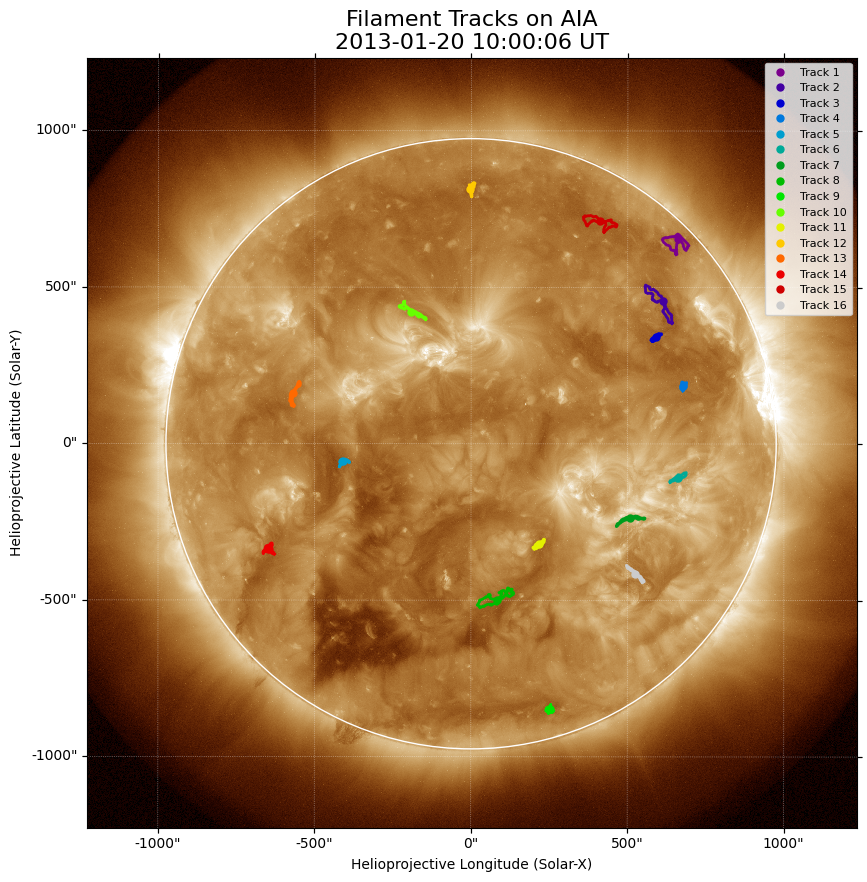

(<Figure size 1000x1000 with 1 Axes>,
 <WCSAxes: title={'center': 'Filament Tracks on AIA\n2013-01-20 10:00:06 UT'}>)

In [53]:
from shapely import wkb
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib as mpl
from astropy.coordinates import SkyCoord
import astropy.units as u

def PlotAllTracksOnAIA(filaments_table, aia_map, png_filename="filaments_on_aia.png", ax=None):

#def PlotAllTracksOnAIA(filaments_table, aia_map, png_filename="filaments_on_aia.png"):
    filaments = filaments_table.copy()

    if "trackno" not in filaments.colnames:
        filaments["trackno"] = range(1, len(filaments)+1)
    track_numbers = sorted(set(filaments["trackno"]))

    cmap = plt.get_cmap("nipy_spectral")
    norm = mpl.colors.Normalize(vmin=0, vmax=max(track_numbers))
    mappable = cm.ScalarMappable(norm=norm, cmap=cmap)

    fig = plt.figure(figsize=(10,10))
    ax = plt.subplot(projection=aia_map)
    aia_map.plot(axes=ax, clip_interval=(1,99.9)*u.percent)
    aia_map.draw_limb(axes=ax, color='white')

    for tn in track_numbers:
        color = mappable.to_rgba(tn)
        track = filaments[filaments["trackno"] == tn]

        xs = [x for x in track["hpc_x"] if x is not None]
        ys = [y for y in track["hpc_y"] if y is not None]
        if xs and ys:
            coords = SkyCoord(xs*u.arcsec, ys*u.arcsec, frame=aia_map.coordinate_frame)
            ax.plot_coord(coords, 'o', color=color, markersize=5, label=f'Track {tn}')

        if "hpc_geom" in track.colnames:
            wkb_hex = track["hpc_geom"][0]
            if wkb_hex:
                try:
                    geom = wkb.loads(bytes.fromhex(wkb_hex))
                except Exception as e:
                    print(f"Track {tn} failed to parse WKB: {e}")
                    continue

                def plot_polygon(polygon):
                    if len(polygon.exterior.coords) > 3:
                        xs_poly = [x for x, y in polygon.exterior.coords]
                        ys_poly = [y for x, y in polygon.exterior.coords]
                        coords_poly = SkyCoord(xs_poly*u.arcsec, ys_poly*u.arcsec, frame=aia_map.coordinate_frame)
                        ax.plot_coord(coords_poly, '-', color=color, linewidth=2)

                if geom.geom_type == "Polygon":
                    plot_polygon(geom)
                elif geom.geom_type == "MultiPolygon":
                    for p in geom.geoms:
                        plot_polygon(p)

    date_str = aia_map.date.utc.strftime("%Y-%m-%d %H:%M:%S UT")
    ax.set_title(f"Filament Tracks on AIA\n{date_str}", fontsize=16)
    ax.legend(loc='upper right', fontsize=8)

    fig.savefig(png_filename, dpi=150, bbox_inches='tight')
    print(f"Saved AIA map with filaments: {png_filename}")
    plt.show()
    return fig, ax
PlotAllTracksOnAIA(filaments, aia_map, png_filename="filaments_on_aia.png")


In [37]:
from sunpy.net import Fido, attrs as a
a.Time("2021-05-23 02:00", "2021-05-23 04:00")
a.Instrument

Attribute Name,Client,Full Name,Description
aia,VSO,AIA,Atmospheric Imaging Assembly
bcs,VSO,BCS,Bragg Crystal Spectrometer
be_continuum,VSO,BE-Continuum,INAF-OACT Barra Equatoriale Continuum Instrument
be_halpha,VSO,BE-Halpha,INAF-OACT Barra Equatoriale Hα Instrument
bigbear,VSO,Big Bear,"Big Bear Solar Observatory, California TON and GONG+ sites"
caii,VSO,CAII,Kanzelhöhe Ca II k Instrument
cds,VSO,CDS,Coronal Diagnostic Spectrometer
celias,VSO,CELIAS,"Charge, Element, and Isotope Analysis System"
cerrotololo,VSO,Cerro Tololo,"Cerro Tololo, Chile GONG+ site"
chp,VSO,chp,Chromospheric Helium-I Imaging Photometer


In [38]:
a.Instrument.bigbear

<sunpy.net.attrs.Instrument(Big Bear: Big Bear Solar Observatory, California TON and GONG+ sites)
object at 0x162de5810>

In [39]:
result_bbso = Fido.search(a.Time("2020-05-23 11:00", "2020-05-26 11:20"), 
                     a.Instrument("Big Bear"), a.Wavelength(6563.0*u.angstrom))

In [ ]:
from sunpy.net import Fido, attrs as a
result_bbso = Fido.search(
    a.Time("2013-01-20 00:00", "2013-01-21 11:20"),
    a.Instrument("Big Bear"), a.Wavelength(6563.0*u.angstrom)
)
files_bbso = Fido.fetch(result_bbso)
print(f"Downloaded BBSO H-alpha map: {files_bbso[0]}")

In [ ]:
import sunpy.map
halpha_map = sunpy.map.Map('/Users/nkarna/Desktop/20130121000054Bh.fits', sequence=False)

# Treat the map as pixel-based
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(halpha_map.data, cmap='gray', origin='lower')
ax.set_title("Filaments (pixel coords) on H-alpha")
plt.show()


In [ ]:
import sunpy.map

# Load map (do NOT recreate it)
halpha_map = sunpy.map.Map(
    '/Users/nkarna/Desktop/20130121000054Bh.fits',
    sequence=False
)

# Add CDELT keywords if missing
if "cdelt1" not in halpha_map.meta:
    halpha_map.meta["cdelt1"] = 1.0   # arcsec / pixel (example)
if "cdelt2" not in halpha_map.meta:
    halpha_map.meta["cdelt2"] = 1.0   # arcsec / pixel (example)

# Optional but usually needed
if "cunit1" not in halpha_map.meta:
    halpha_map.meta["cunit1"] = "arcsec"
if "cunit2" not in halpha_map.meta:
    halpha_map.meta["cunit2"] = "arcsec"


In [59]:
import sunpy.map

halpha_map = sunpy.map.Map('/Users/nkarna/Desktop/20130121000054Bh.fits', sequence=False)

# Print all header keywords
for key, value in halpha_map.meta.items():
    print(f"{key}: {value}")



simple: True
bitpix: 16
naxis: 2
naxis1: 2048
naxis2: 2048
extend: True
gongkey1: --------- Gong Keywords Section 1: Solarsoft ----------------
origin: National Solar Observatory -- GONG
obs-site: NSO/GONG NETWORK
telescop: NSO-GONG
obs-url: http://gong.nso.edu
date: 2013-01-21T00:01:20
date-obs: 2013-01-21T00:00:54
time-obs: 00:00:54
wavelnth: 6562.808
wcsname: Heliocentric-cartesian (approximate)
ctype1: GONGX
ctype2: GONGY
crval1: 0.0
crval2: 0.0
crpix1: 1024.0
crpix2: 1024.0
eph_ra: -0.989117894
eph_dec: -0.347549653
imtype: H-ALPHA
imgmn01: 1815.534057617
imgrms01: 1445.533325195
imgskw01: -0.350718468
imgmin01: 0
imgmax01: 4326
imgadv01: 1407.302246094
imgvar01: 2089566.625
imgkur01: -1.763344526
gongkey2: --------- Gong Keywords Section 2: Raw ----------------
iraf-tlm: 2013-01-21T00:01:20
sitename: BB
site: BB
j2000: 4768.50059354
lst: 0.06660878
zenith: 1.377163478
ra: -0.989117894
dec: -0.347549653
pa: -0.13086765
ha: 1.055726674
beta: 0.622503829
radius: 900
eroll: 1.3397585

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Saved H-alpha map with filaments (manual alignment): filaments_on_halpha_manual.png


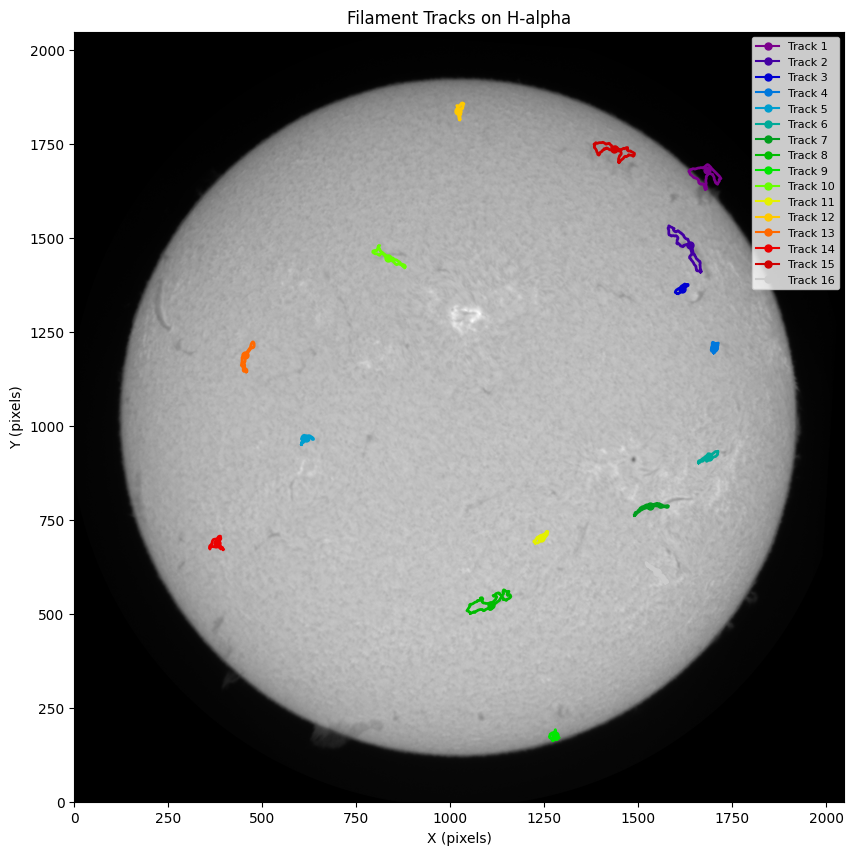

(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': 'Filament Tracks on H-alpha'}, xlabel='X (pixels)', ylabel='Y (pixels)'>)

In [70]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib as mpl
from shapely import wkb
from astropy.table import Table
import sunpy.map
from astropy.time import Time




def PlotAllTracksOnHalphaManual(filaments_table, halpha_map, scale=1, png_filename="filaments_on_halpha_manual.png", ax=None):
    """
    Plot HEK filaments on H-alpha map in pixel coordinates using manual alignment.

    Parameters
    ----------
    filaments_table : astropy Table or list of dicts
        Must contain 'trackno', 'hpc_x', 'hpc_y', optionally 'hpc_geom' (arcsec)
    halpha_map : SunPy map
        H-alpha map (pixel-only)
    scale : float
        Arcsec per pixel
    """
    filaments = filaments_table.copy() if hasattr(filaments_table, "copy") else filaments_table

    # Assign track numbers if missing
    if hasattr(filaments, "colnames"):
        if "trackno" not in filaments.colnames:
            filaments["trackno"] = range(1, len(filaments)+1)
        track_numbers = sorted(set(filaments["trackno"]))
    else:
        track_numbers = [f['trackno'] for f in filaments]

    # Color map
    cmap = plt.get_cmap("nipy_spectral")
    norm = mpl.colors.Normalize(vmin=0, vmax=max(track_numbers))
    mappable = cm.ScalarMappable(norm=norm, cmap=cmap)

    # Disk center in pixels
    xc = halpha_map.data.shape[1] / 2
    yc = halpha_map.data.shape[0] / 2

    # Figure
    fig, ax = plt.subplots(figsize=(10,10))
    ax.imshow(halpha_map.data, cmap='gray', origin='lower')
    ax.set_xlim(0, halpha_map.data.shape[1])
    ax.set_ylim(0, halpha_map.data.shape[0])
    ax.set_xlabel("X (pixels)")
    ax.set_ylabel("Y (pixels)")
    ax.set_title("Filament Tracks on H-alpha")
    ax.set_aspect('equal')
   # ax.set_title(f"Filament Tracks on H-alpha")

    ax.legend(loc='upper right', fontsize=8)

    for tn in track_numbers:
        color = mappable.to_rgba(tn)

        if hasattr(filaments, "colnames"):
            track = filaments[filaments["trackno"] == tn]
            xs = [x for x in track["hpc_x"] if x is not None]
            ys = [y for y in track["hpc_y"] if y is not None]
            wkb_hex = track["hpc_geom"][0] if "hpc_geom" in track.colnames else None
        else:
            track = next(f for f in filaments if f['trackno'] == tn)
            xs = track['hpc_x']
            ys = track['hpc_y']
            wkb_hex = track.get('hpc_geom', None)

        # HPC -> pixel
        if xs and ys:
            px = [xc + x/scale for x in xs]
            py = [yc + y/scale for y in ys]
            ax.plot(px, py, 'o-', color=color, markersize=5, label=f'Track {tn}')

        # WKB polygons
        if wkb_hex:
            try:
                geom = wkb.loads(bytes.fromhex(wkb_hex))
            except Exception as e:
                print(f"Track {tn} failed to parse WKB: {e}")
                continue

            def plot_polygon(polygon):
                xs_poly, ys_poly = zip(*polygon.exterior.coords)
                px_poly = [xc + x/scale for x in xs_poly]
                py_poly = [yc + y/scale for y in ys_poly]
                ax.plot(px_poly, py_poly, '-', color=color, linewidth=2)

            if geom.geom_type == "Polygon":
                plot_polygon(geom)
            elif geom.geom_type == "MultiPolygon":
                for p in geom.geoms:
                    plot_polygon(p)

    ax.legend(loc='upper right', fontsize=8)
    fig.savefig(png_filename, dpi=150, bbox_inches='tight')
    print(f"Saved H-alpha map with filaments (manual alignment): {png_filename}")
    plt.show()
    return fig, ax

PlotAllTracksOnHalphaManual(filaments, halpha_map)


Saved H-alpha map with filaments (manual alignment): filaments_on_halpha_manual.png


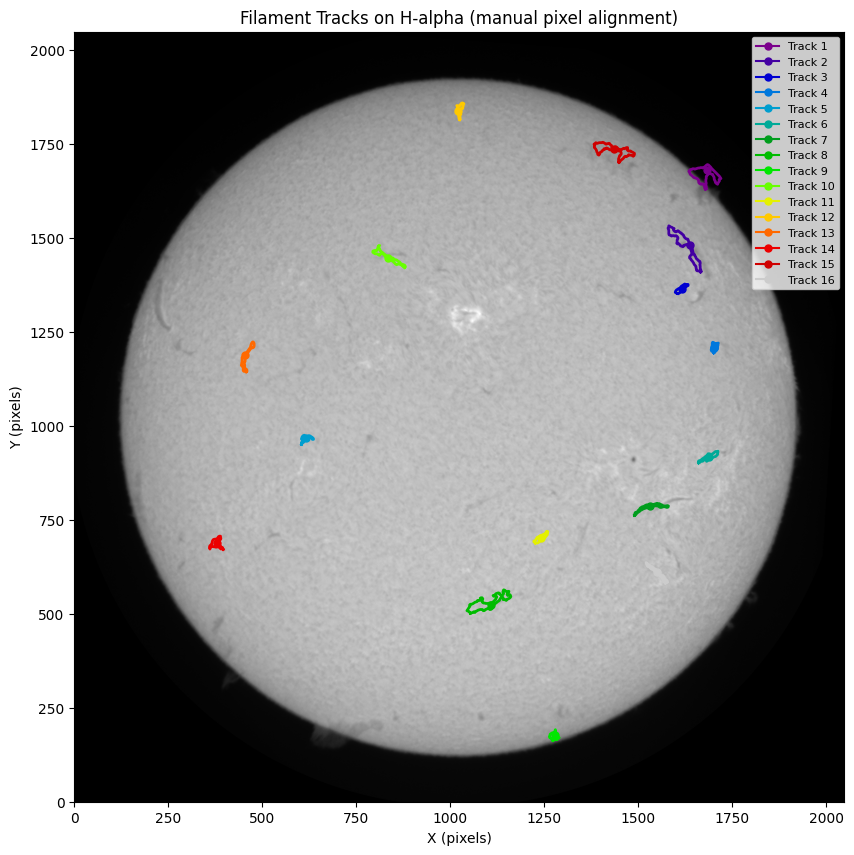

(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': 'Filament Tracks on H-alpha (manual pixel alignment)'}, xlabel='X (pixels)', ylabel='Y (pixels)'>)

Saved AIA map with filaments: filaments_on_aia.png


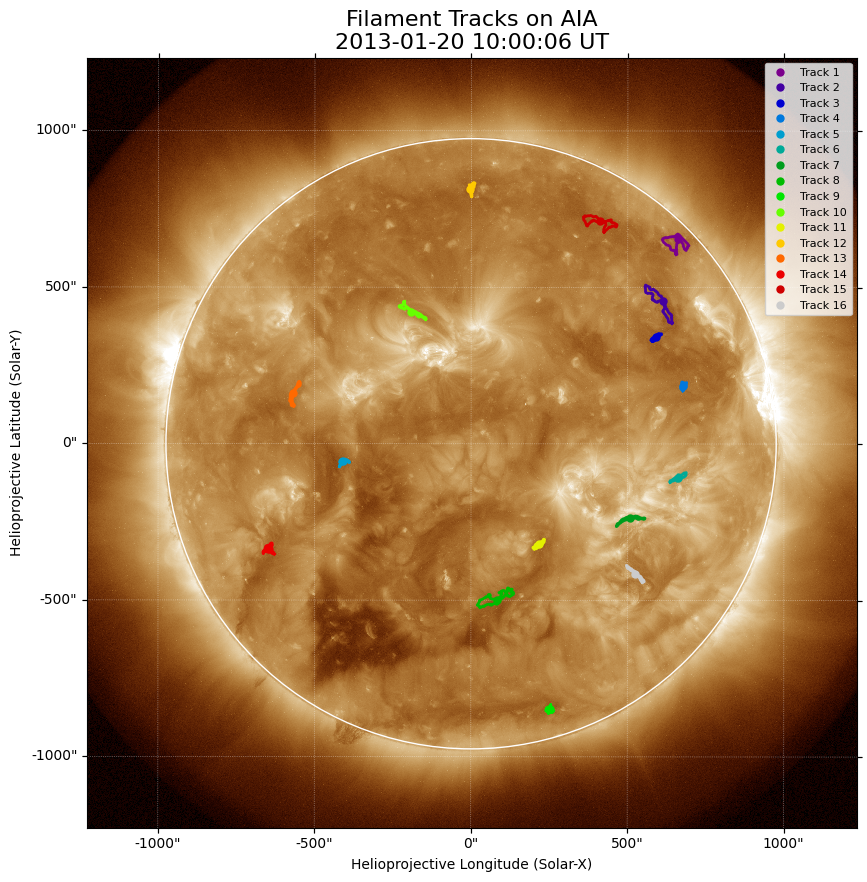

(<Figure size 1000x1000 with 1 Axes>,
 <WCSAxes: title={'center': 'Filament Tracks on AIA\n2013-01-20 10:00:06 UT'}>)

In [43]:
PlotAllTracksOnAIA(filaments, aia_map, png_filename="filaments_on_aia.png")

Saved AIA map with filaments: filaments_on_aia.png


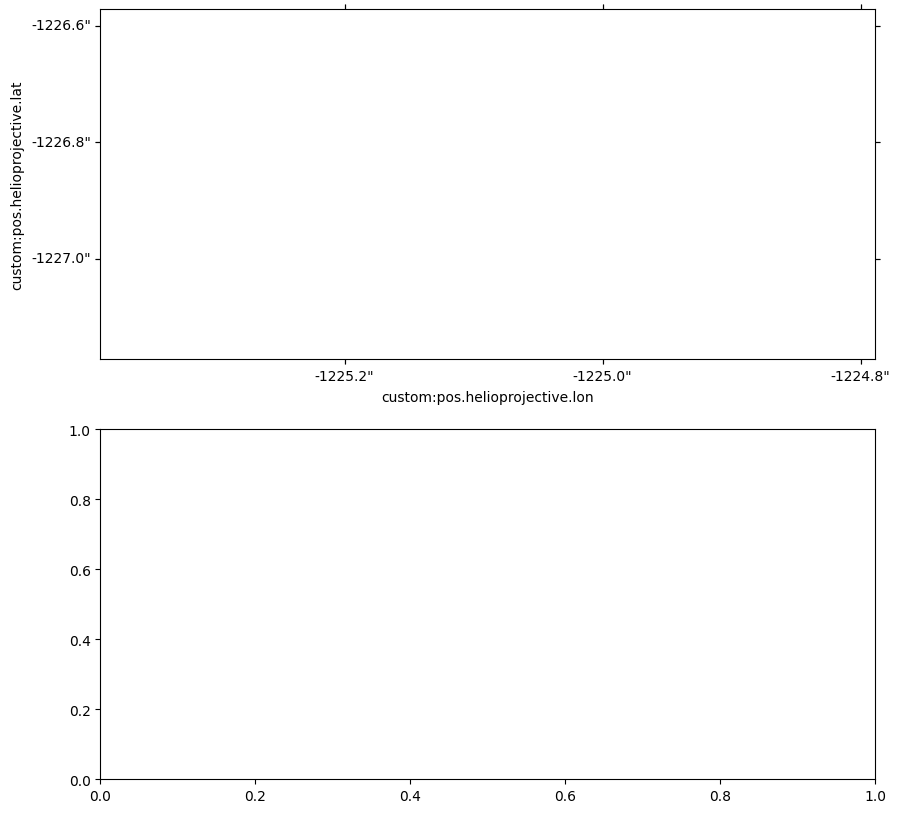

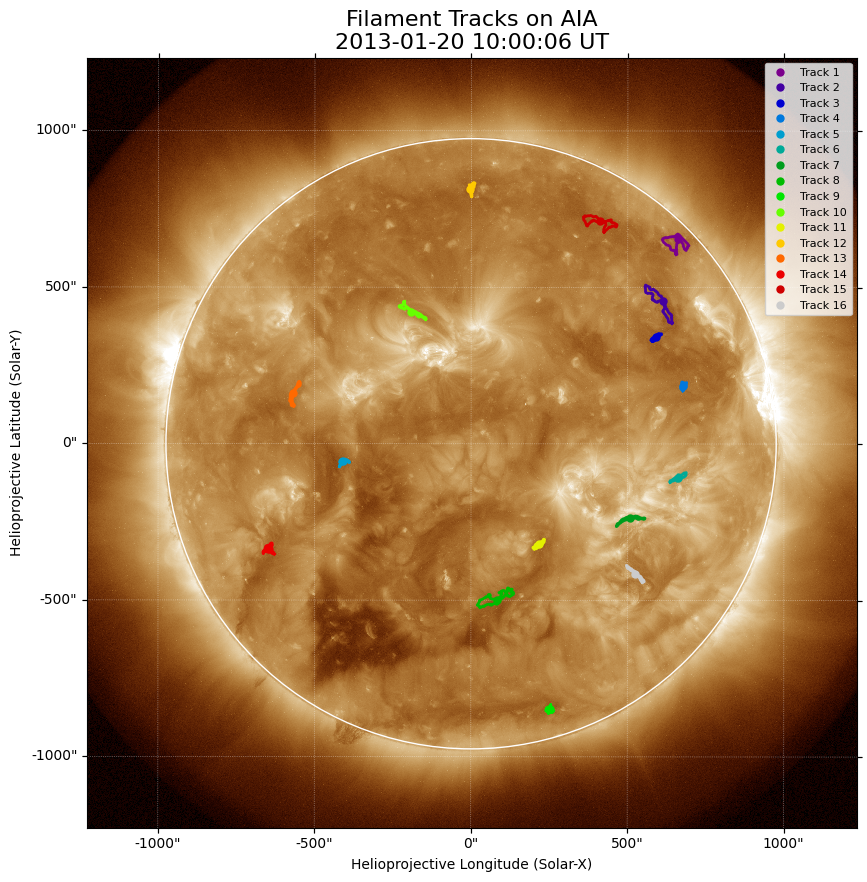

Saved H-alpha map with filaments (manual alignment): filaments_on_halpha_manual.png


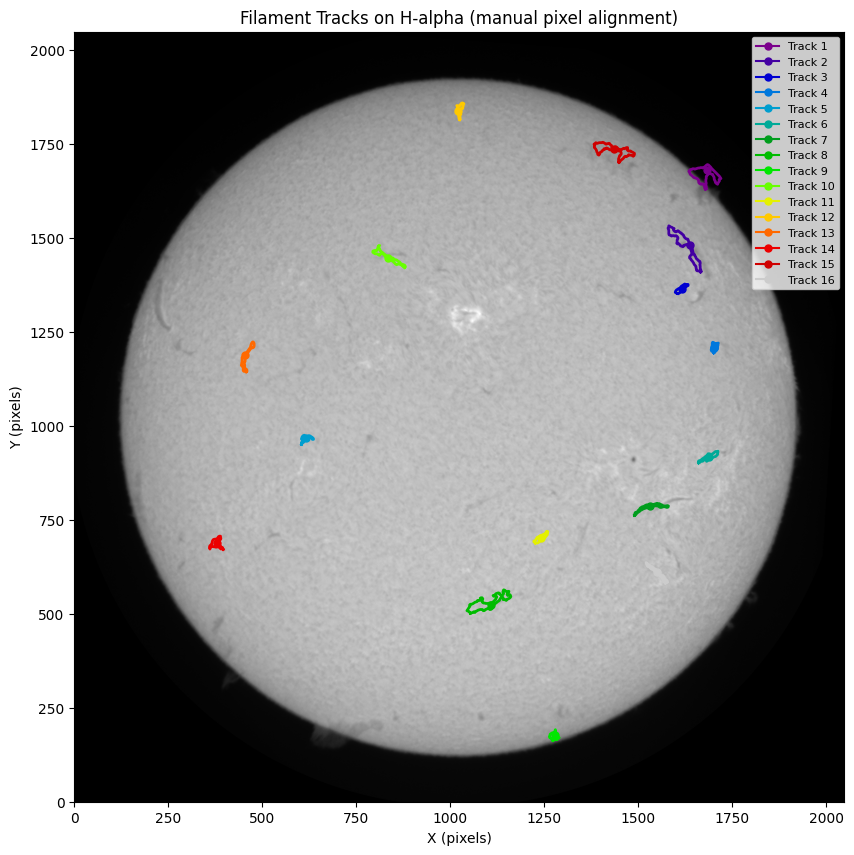

<Figure size 640x480 with 0 Axes>

In [56]:
fig, axs = plt.subplots(2, figsize=(10, 10))

# --- AIA ---
axs[0].remove()
ax_aia = fig.add_subplot(2, 1, 1, projection=aia_map)
PlotAllTracksOnAIA(filaments, aia_map, ax=ax_aia)

# --- H-alpha ---
PlotAllTracksOnHalphaManual(filaments, halpha_map, ax=axs[1])

plt.tight_layout()
plt.show()

